# Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

# Importing Dataset

In [2]:
df = pd.read_csv('Tesla.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close,Unnamed: 7,Unnamed: 8
0,6/29/2010,19.00,25.00,17.540000,23.889999,18766300.0,23.889999,NaN,NaN
1,6/30/2010,25.79,30.42,23.299999,23.830000,17187100.0,23.830000,NaN,NaN
2,7/1/2010,25.00,25.92,20.270000,21.960000,8218800.0,21.960000,NaN,NaN
3,7/2/2010,23.00,23.10,18.710000,19.200000,5139800.0,19.200000,NaN,NaN
4,7/6/2010,20.00,20.00,15.830000,16.110000,6866900.0,16.110000,NaN,NaN


In [3]:
df.shape

(310, 9)

In [4]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close,Unnamed: 7
count,51.000000,52.000000,52.000000,52.000000,5.200000e+01,52.000000,0.0
mean,17.936470,18.426923,17.159231,17.718461,2.463150e+06,17.699231,NaN
std,1.918477,2.505507,1.293811,1.631179,3.739526e+06,1.619948,NaN
min,15.890000,16.000000,14.980000,15.770000,2.355000e+05,15.770000,NaN
25%,16.860000,17.137500,16.457500,16.692500,5.334750e+05,16.692500,NaN
50%,17.580000,17.900000,17.010000,17.385000,1.078100e+06,17.385000,NaN
75%,18.335000,18.742500,17.610000,18.207500,2.466950e+06,18.152500,NaN
max,25.790000,30.420000,23.299999,23.889999,1.876630e+07,23.889999,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        310 non-null    str    
 1   Open        51 non-null     float64
 2   High        52 non-null     float64
 3   Low         52 non-null     float64
 4   Close       52 non-null     float64
 5   Volume      52 non-null     float64
 6   Adj Close   52 non-null     float64
 7   Unnamed: 7  0 non-null      float64
 8   Unnamed: 8  2 non-null      str    
dtypes: float64(7), str(2)
memory usage: 24.7 KB


# Exploratory Data Analysis

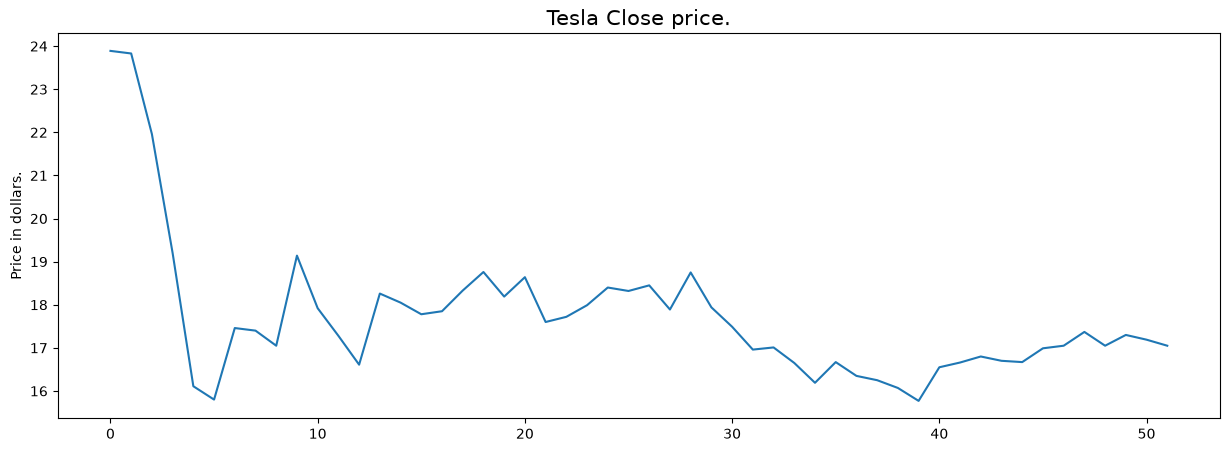

In [6]:
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title('Tesla Close price.', fontsize=15)
plt.ylabel('Price in dollars.')
plt.show()

In [7]:
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close,Unnamed: 7,Unnamed: 8
0,6/29/2010,19.00,25.00,17.540000,23.889999,18766300.0,23.889999,NaN,NaN
1,6/30/2010,25.79,30.42,23.299999,23.830000,17187100.0,23.830000,NaN,NaN
2,7/1/2010,25.00,25.92,20.270000,21.960000,8218800.0,21.960000,NaN,NaN
3,7/2/2010,23.00,23.10,18.710000,19.200000,5139800.0,19.200000,NaN,NaN
4,7/6/2010,20.00,20.00,15.830000,16.110000,6866900.0,16.110000,NaN,NaN


In [8]:
df[df['Close'] == df['Adj Close']].shape

(44, 9)

In [9]:
df = df.drop(['Adj Close'], axis=1)

In [10]:
df.isnull().sum()

Date            0
Open          259
High          258
Low           258
Close         258
Volume        258
Unnamed: 7    310
Unnamed: 8    308
dtype: int64

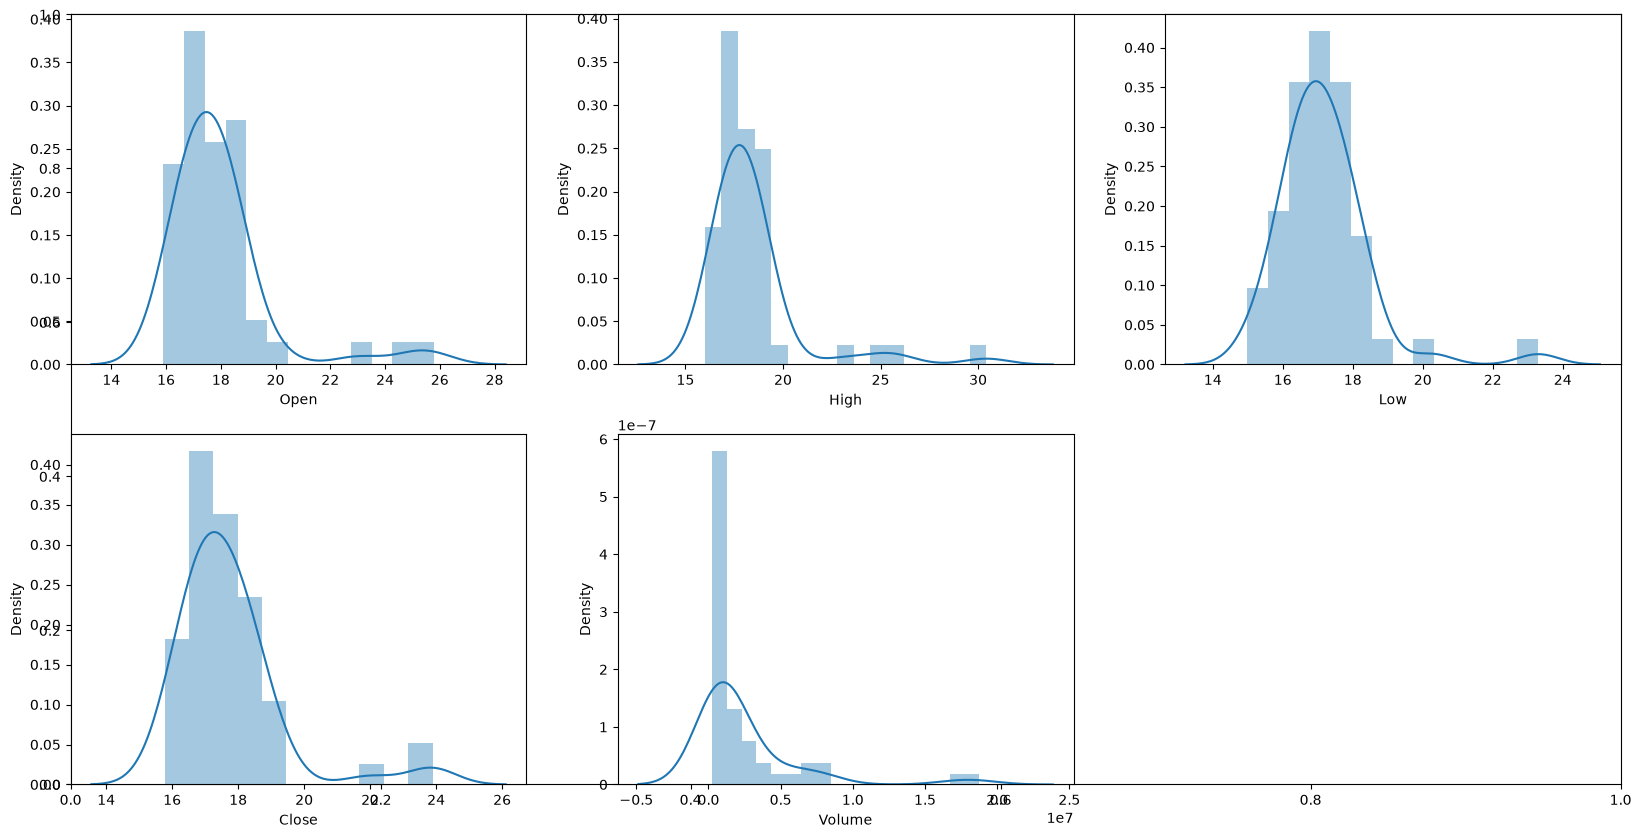

In [11]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.distplot(df[col])
plt.show()

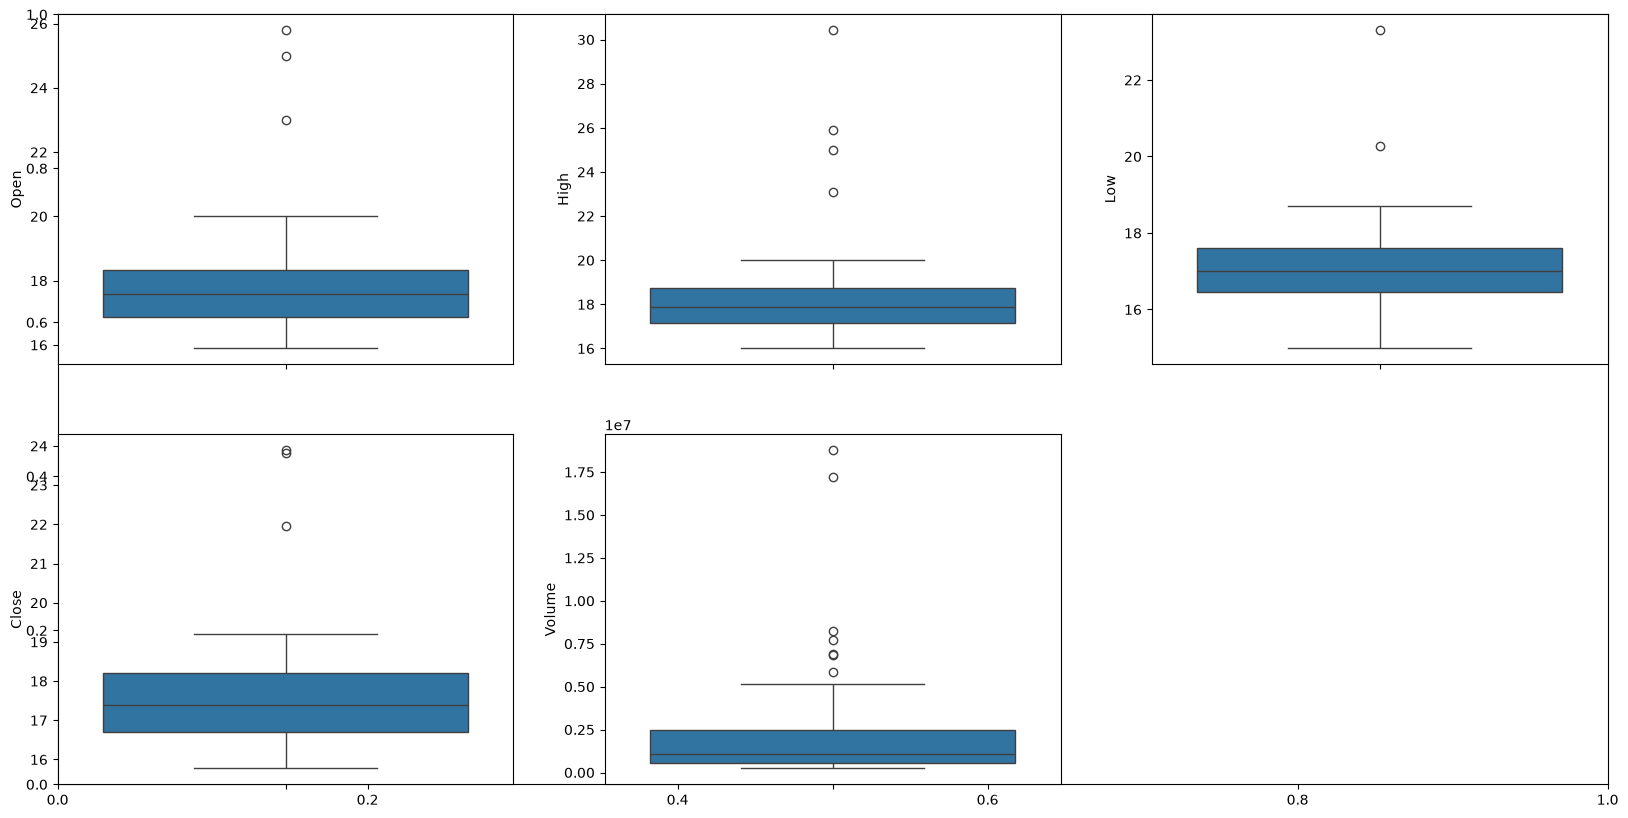

In [12]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.boxplot(df[col])
plt.show()

# Feature Engineering

In [13]:
splitted = df['Date'].str.split('/', expand=True)

df['day'] = splitted[1].astype('int')
df['month'] = splitted[0].astype('int')
df['year'] = splitted[2].astype('int')

df.head()

,Date,Open,High,Low,Close,Volume,Unnamed: 7,Unnamed: 8,day,month,year
0,6/29/2010,19.00,25.00,17.540000,23.889999,18766300.0,NaN,NaN,29,6,2010
1,6/30/2010,25.79,30.42,23.299999,23.830000,17187100.0,NaN,NaN,30,6,2010
2,7/1/2010,25.00,25.92,20.270000,21.960000,8218800.0,NaN,NaN,1,7,2010
3,7/2/2010,23.00,23.10,18.710000,19.200000,5139800.0,NaN,NaN,2,7,2010
4,7/6/2010,20.00,20.00,15.830000,16.110000,6866900.0,NaN,NaN,6,7,2010


In [14]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head()

,Date,Open,High,Low,Close,Volume,Unnamed: 7,Unnamed: 8,day,month,year,is_quarter_end
0,6/29/2010,19.00,25.00,17.540000,23.889999,18766300.0,NaN,NaN,29,6,2010,1
1,6/30/2010,25.79,30.42,23.299999,23.830000,17187100.0,NaN,NaN,30,6,2010,1
2,7/1/2010,25.00,25.92,20.270000,21.960000,8218800.0,NaN,NaN,1,7,2010,0
3,7/2/2010,23.00,23.10,18.710000,19.200000,5139800.0,NaN,NaN,2,7,2010,0
4,7/6/2010,20.00,20.00,15.830000,16.110000,6866900.0,NaN,NaN,6,7,2010,0


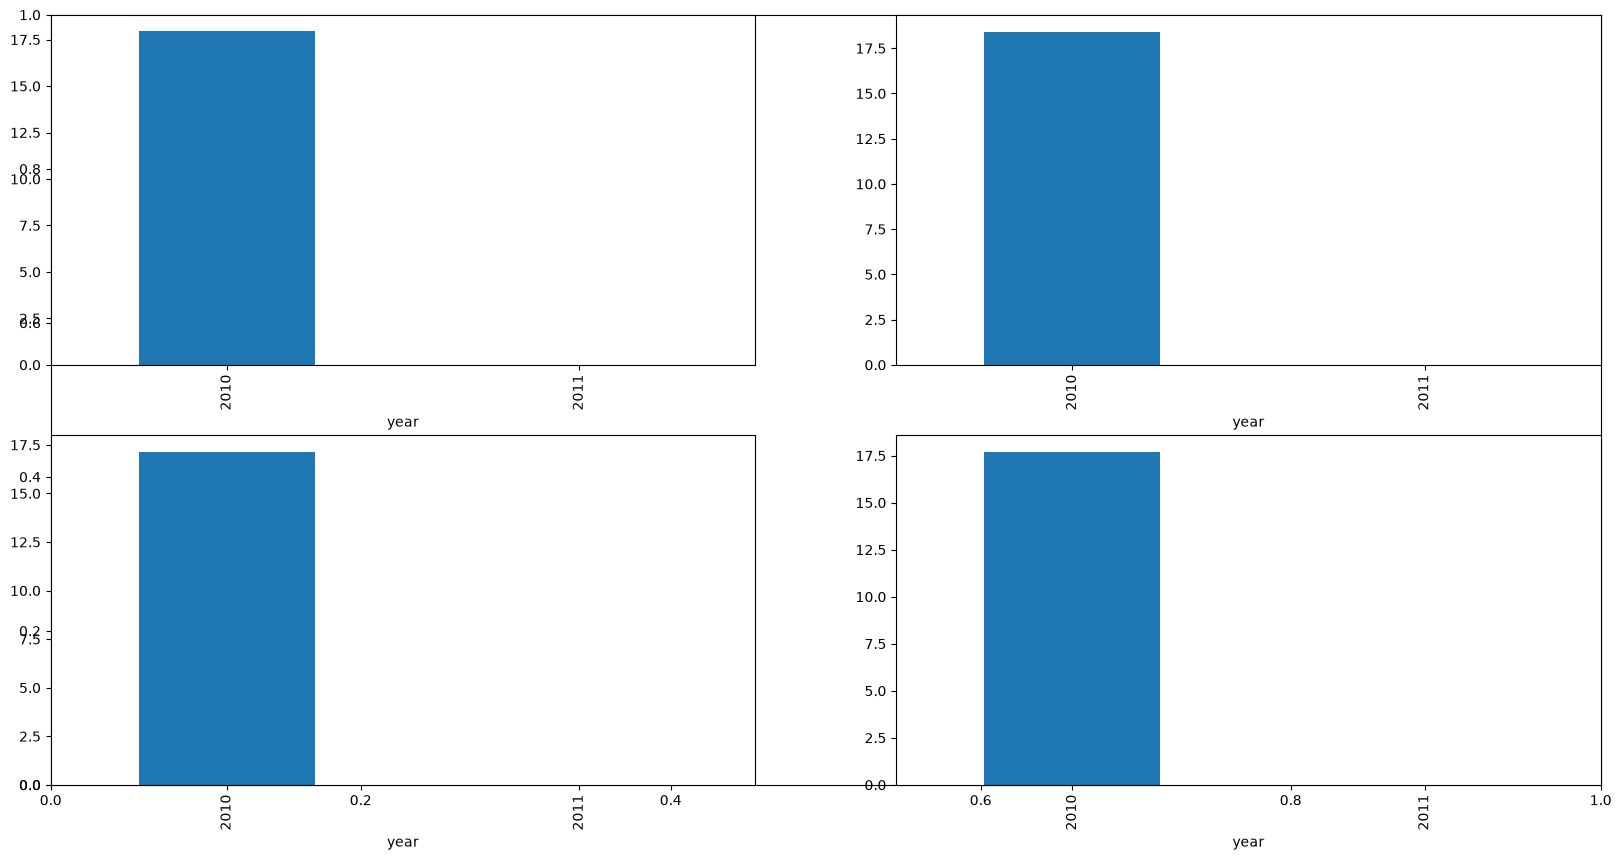

In [15]:
data_grouped = df.drop('Date', axis=1).groupby('year').mean(numeric_only=True)
plt.subplots(figsize=(20, 10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2,2,i+1)
    data_grouped[col].plot.bar()
plt.show()

# This code is modified by Susobhan Akhuli

In [16]:
# df.drop('Date', axis=1).groupby('is_quarter_end').mean()
df.drop('Date', axis=1).groupby('is_quarter_end').mean(numeric_only=True)

,Open,High,Low,Close,Volume,Unnamed: 7,day,month,year
is_quarter_end,,,,,,,,,
0,17.791522,18.104468,17.042766,17.494255,1.934766e+06,NaN,15.586854,6.145540,2010.450704
1,19.270000,21.458000,18.254000,19.826000,7.429960e+06,NaN,15.690722,7.979381,2010.319588


In [17]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

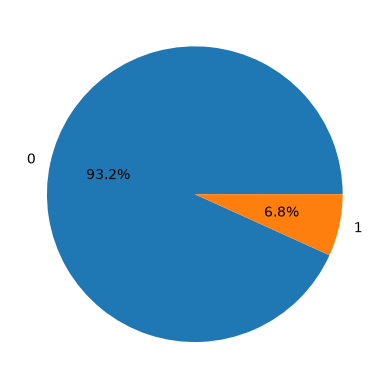

In [18]:
plt.pie(df['target'].value_counts().values, 
        labels=[0, 1], autopct='%1.1f%%')
plt.show()